This script was written by Celeste Cohen and performs gene clustering based on heteroskedasticity results

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sb
from sklearn import preprocessing
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import math
from matplotlib.ticker import ScalarFormatter

In [3]:
res_fname="rna-seq/analysis/variance/results/adj_heteroskedasticity_betweentimepoints.tsv"
vars_fname="rna-seq/analysis/variance/results/gene_variance_mean_pertimepoint.tsv"
cluster_genes_dir="rna-seq/analysis/variance/results/variance_cluster_genes_sh50/"
cluster_summaries_fname="rna-seq/analysis/variance/results/variance_cluster_summary_sh50.tsv"
fig_dir="rna-seq/analysis/variance/results/"

In [4]:
df=pd.read_csv(res_fname,sep='\t')
df.head()

,gene,timepoints,variance_ratio,Fstat,pval,qval,BYqval,log2FC,BH_adj_pval_within_tp
0,ENSG00000000003,timepoint_12weeks_vs_timepoint_20weeks,0.965157,0.039927,0.841668,0.945298,1.0,-0.051165,0.972392
1,ENSG00000000419,timepoint_12weeks_vs_timepoint_20weeks,1.003573,0.033383,0.855066,0.950254,1.0,0.005145,0.975341
2,ENSG00000000457,timepoint_12weeks_vs_timepoint_20weeks,0.951691,0.109834,0.740409,0.903360,1.0,-0.071435,0.949980
3,ENSG00000000460,timepoint_12weeks_vs_timepoint_20weeks,0.822590,1.802918,0.179690,0.485018,1.0,-0.281755,0.702058
4,ENSG00000000938,timepoint_12weeks_vs_timepoint_20weeks,1.017485,0.429450,0.512422,0.781855,1.0,0.025007,0.888047


In [5]:
FCthresh=np.log2(1.5)

In [6]:
#filter out genes with no sig variance change
keepgenes = np.unique(df[(df['BYqval'] < 0.05) & (df['log2FC'].abs() > FCthresh)]['gene'])
df=df[df['gene'].isin(keepgenes)]

In [7]:
# set log2FC to 0 for time-points where heteroskedasticity is not significant (p < 0.05) 
df['log2FC_clus']=np.where((df['BH_adj_pval_within_tp'] < 0.05) & (np.abs(df['log2FC']) > FCthresh), df['log2FC'],0)
df_pivot= df.pivot(index='gene', columns='timepoints', values='log2FC_clus')
df_pivot.columns = df_pivot.columns.str.replace(r".*_(\d+)weeks_vs_.*_(\d+)weeks", r"\1v\2", regex=True)
df_pivot.head()

timepoints,12v20,12v28,12v36,20v28,20v36,28v36
gene,,,,,,
ENSG00000000457,0.0,0.000000,0.000000,0.0,0.655014,0.0
ENSG00000001084,0.0,0.757965,1.178246,0.0,0.857216,0.0
ENSG00000003756,0.0,0.000000,0.607503,0.0,0.000000,0.0
ENSG00000004142,0.0,0.000000,0.667589,0.0,0.000000,0.0
ENSG00000004779,0.0,-0.665920,-0.697115,0.0,0.000000,0.0


In [8]:
# standardize df
y=df_pivot.index.to_numpy()
X=df_pivot.to_numpy()
X_sc=preprocessing.StandardScaler().fit_transform(X)

In [9]:
#calculate average wihtin cluster squared distance
def avg_within_cluster_sq_dist(X, labels):
    ssd = 0
    total_points = 0
    for label in np.unique(labels):
        cluster_points = X[labels == label]
        centroid = cluster_points.mean(axis=0)
        distances = pairwise_distances(cluster_points, [centroid])
        ssd += (distances ** 2).sum()
        total_points += len(cluster_points)
    return ssd / total_points

In [10]:
#calculate inertia ie sum of squared distances
def inertia_manual(X, labels):
    ssd = 0
    #total_points = 0
    for label in np.unique(labels):
        cluster_points = X[labels == label]
        centroid = cluster_points.mean(axis=0)
        distances = pairwise_distances(cluster_points, [centroid])
        ssd+=(distances ** 2).sum()
        #total_points += len(cluster_points)
    return ssd

In [11]:
# cluster by looping through k (n cluster) values
results = []

for k in range(3, 16):
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X_sc)
    
    #avg_dist = model.inertia_ /k
    avg_dist=inertia_manual(X_sc, labels)#/k included /k originally but actually makes more sense not to
    #avg_dist = avg_within_cluster_sq_dist(X_sc, labels)
    
    # Count genes in smallest cluster
    unique, counts = np.unique(labels, return_counts=True)
    smallest_cluster_size = counts.min()
    
    results.append({'k': k, 'avg_within_cluster_sq_dist': avg_dist, 'smallest_cluster_size': smallest_cluster_size})

cluschoice_results = pd.DataFrame(results)

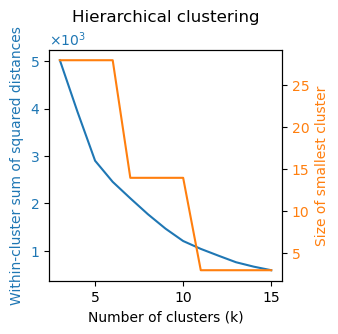

In [12]:
fig, ax1 = plt.subplots(figsize=(3,3))

color = 'tab:blue'
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Within-cluster sum of squared distances', color=color)
ax1.plot(cluschoice_results['k'], cluschoice_results['avg_within_cluster_sq_dist'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Size of smallest cluster', color=color)
ax2.plot(cluschoice_results['k'], cluschoice_results['smallest_cluster_size'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Hierarchical clustering')
# Supplementary Figure 28
plt.savefig(fig_dir+'clusternumber_decisionplot_sh50.pdf',bbox_inches='tight')
plt.show()

In [13]:
cluschoice_results
# Choose k = 6 because 
# 1. it is the largest number of clusters before the min cluster size drops
# 2. It represents an elbow in the within-cluster distance

,k,avg_within_cluster_sq_dist,smallest_cluster_size
0,3,5018.812576,28
1,4,3932.002889,28
2,5,2899.537304,28
3,6,2453.980148,28
4,7,2107.117641,14
5,8,1771.001067,14
6,9,1466.906692,14
7,10,1206.531969,14
8,11,1040.605000,3
9,12,897.819121,3


In [14]:
k=6
#model = KMeans(n_clusters=k,random_state=0)
model = AgglomerativeClustering(n_clusters=k)
labels = model.fit_predict(X_sc)

In [15]:
#make a gene-cluster map df
df_pivot.columns.name = None
df_pivot['cluster_label']=labels
gene_cluster_map=df_pivot[['cluster_label']].copy() 
gene_cluster_map['gene']=gene_cluster_map.index.to_numpy() 
gene_cluster_map.reset_index(drop=True, inplace=True)

In [16]:
vars=pd.read_csv(vars_fname,sep='\t')
vars['scaled_var'] = vars.groupby('gene')['variance'].transform(lambda x: (x - x.mean()) / x.std())
vars.head()

,timepoint,gene,uncorrected_variance,variance,uncorrected_mean,mean,scaled_var
0,12 weeks,ENSG00000000003,1.733677,1.512334,-1.708140,-3.170413e-17,0.197862
1,12 weeks,ENSG00000000419,0.086618,0.065357,5.156278,-4.076354e-18,0.208634
2,12 weeks,ENSG00000000457,0.187542,0.125110,3.915295,5.814005e-18,-0.680011
3,12 weeks,ENSG00000000460,0.374499,0.337980,0.597251,-1.878152e-17,1.485158
4,12 weeks,ENSG00000000938,0.175038,0.148347,8.447829,-5.013520e-19,-0.802256


In [17]:
plotvars=vars.merge(gene_cluster_map, on='gene', how='left')
plotvars = plotvars.dropna()
plotvars['week'] = plotvars['timepoint'].str.extract(r'(\d+)').astype(int)

In [18]:
plotvars

,timepoint,gene,uncorrected_variance,variance,uncorrected_mean,mean,scaled_var,cluster_label,week
2,12 weeks,ENSG00000000457,0.187542,0.125110,3.915295,5.814005e-18,-0.680011,0.0,12
7,12 weeks,ENSG00000001084,0.266525,0.239284,2.964656,-9.249439e-18,-1.042989,0.0,12
36,12 weeks,ENSG00000003756,0.257048,0.157804,6.367898,-2.148617e-18,-1.005894,5.0,12
39,12 weeks,ENSG00000004142,0.136511,0.102231,5.331957,2.625575e-18,-1.073381,5.0,12
50,12 weeks,ENSG00000004779,0.152406,0.129754,4.806641,-8.379501e-18,1.111274,1.0,12
...,...,...,...,...,...,...,...,...,...
75063,36 weeks,ENSG00000286419,3.012926,2.653809,-3.183836,3.800592e-17,0.513907,5.0,36
75146,36 weeks,ENSG00000287193,1.808360,1.607915,-1.321738,7.495158e-18,-0.019536,1.0,36
75155,36 weeks,ENSG00000287263,0.502352,0.288164,5.222512,7.413570e-18,1.237147,0.0,36
75160,36 weeks,ENSG00000287312,2.502792,2.054585,0.162615,3.093877e-19,-0.369388,1.0,36


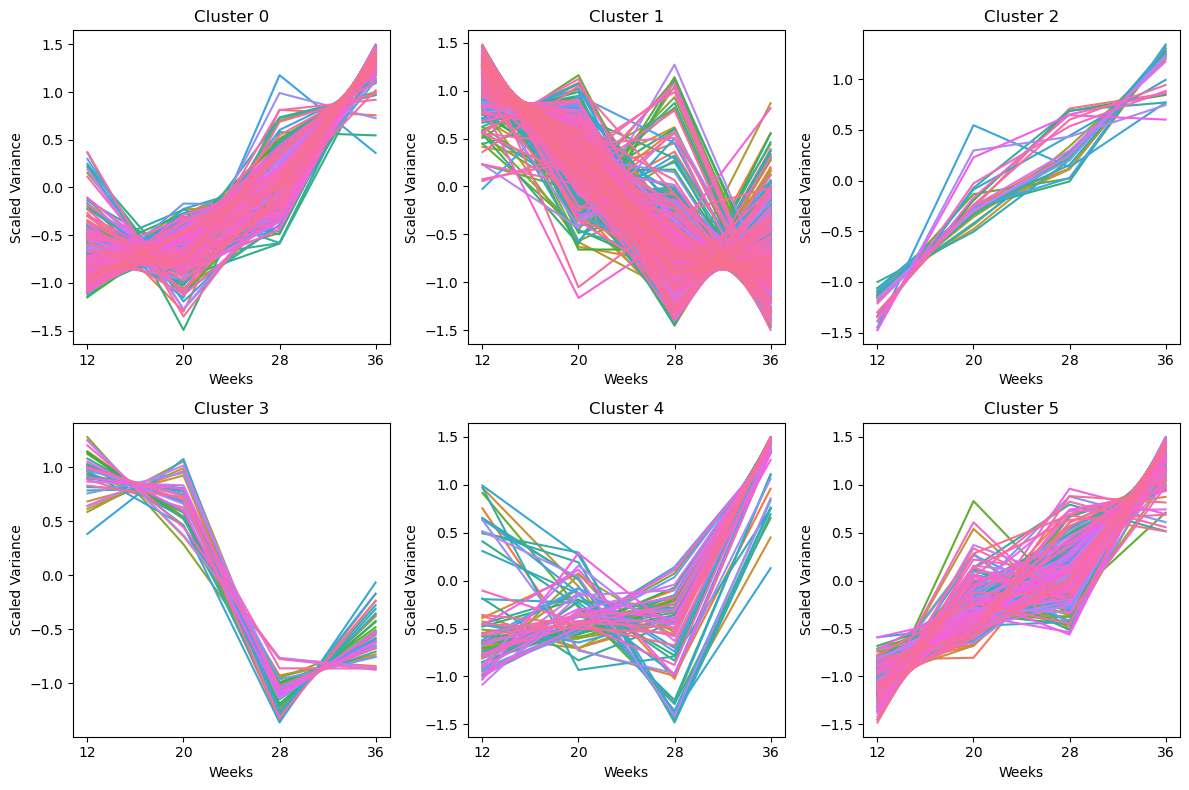

In [19]:
cols = 3
rows = math.ceil(k / cols)

timepoints = sorted(plotvars['week'].unique())

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4)) #, sharex=True, sharey=True
axes = axes.flatten()

for clus in range(k):
    ax = axes[clus]
    plotvars_subset=plotvars[plotvars['cluster_label']==clus]
    sb.lineplot(data=plotvars_subset, x='week', y='scaled_var', hue='gene',legend=False,ax=ax)

    ax.set_xlabel('Weeks')
    ax.set_ylabel('Scaled Variance')
    ax.set_title('Cluster '+str(clus))
    ax.set_xticks(timepoints)

for j in range(clus + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(fig_dir+'vartrajectories_6clusters_sh50.pdf',bbox_inches='tight')
plt.show()

In [20]:
features=[col for col in df_pivot.columns if any(char.isdigit() for char in col)] #in case there's already a clusters column
df_pivot['cluster_label']=labels

cluster=[]
n_genes=[]
timepoints=[]
mean_log2FC=[]
sd_log2FD=[]
prop_genes_nonsig=[]
prop_genes_up=[]
prop_genes_down=[]
for clus in np.unique(labels):
    df_subset=df_pivot[df_pivot['cluster_label']==clus]
    for tp in features:
        cluster.append(clus)
        n_genes_temp=df_subset.shape[0]
        n_genes.append(n_genes_temp)
        timepoints.append(tp)
        mean_log2FC.append(np.mean(df_subset[tp]))
        sd_log2FD.append(np.std(df_subset[tp]))
        prop_genes_nonsig.append(df_subset[df_subset[tp]==0].shape[0]/n_genes_temp)
        prop_genes_up.append(df_subset[df_subset[tp]>0].shape[0]/n_genes_temp)
        prop_genes_down.append(df_subset[df_subset[tp]<0].shape[0]/n_genes_temp)
cluster_summaries=pd.DataFrame({'cluster':cluster,'n_genes':n_genes,'timepoints':timepoints,'mean_log2FC':mean_log2FC,
                                'sd_log2FD':sd_log2FD,'prop_genes_nonsig':prop_genes_nonsig,'prop_genes_up':prop_genes_up,
                                'prop_genes_down':prop_genes_down})

cluster_summaries.to_csv(cluster_summaries_fname,sep='\t',index=False,header=True)

In [ ]:
for clus in range(k):
    gene_cluster_map[gene_cluster_map['cluster_label']==clus]['gene'].to_csv(cluster_genes_dir+'cluster'+str(clus)+'.txt',
                                                                             sep='\t',index=False,header=False)